# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Refuerzo, Paul Adam
- _Student No._: 2024-09465
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [2]:
def fixedpoint(f, xold, kmax=200, tol=1.e-8):
    for k in range(1, kmax):
        xnew = f(xold)
        
        if abs(xnew - xold) < tol:
            break

        xold = xnew    
    else:
        xnew = None

    return xnew

In [3]:
def bisection(f, x1, x2, kmax=200, tol=1.e-8):
    for k in range(1, kmax):
        f1 = f(x1)
        f2 = f(x2)

        xmid = (x1+x2)/2
        fmid = f(xmid)
        
        if fmid*f1 < 0:
            x2 = xmid
        else:
            x1 = xmid

        xmidnew = (x1+x2)/2
        xdiff = abs(xmidnew-xmid)

        if abs(xdiff/xmidnew) < tol:
            break
    else:
        xmidnew = None

    return xmidnew     

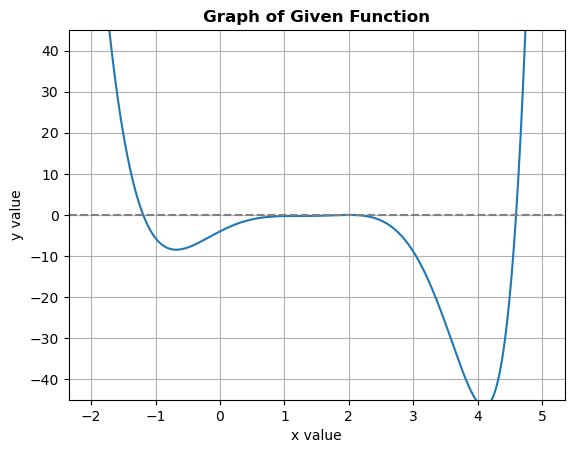

In [4]:
def g1(x):
    return (x - 2)**2

def g2(x):
    return x**3 - np.exp(x) + 2
    
def f(x):
    #y = - x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
    y = -g1(x) * g2(x)
    return y

xs = np.linspace(-2, 5, 400)
ys = f(xs)

plt.plot(xs, ys)
plt.title('Graph of Given Function', fontweight='bold')
plt.ylim(-45, 45)
plt.xlabel('x value')
plt.ylabel('y value')
plt.axhline(y=0, color='gray', linestyle='--')
plt.grid()
plt.show()

In [5]:
print('Roots from fixed point method:')

#for xolds in range(-1, 5):
    #fixedpointroot = fixedpoint(g1, xolds)
    #if fixedpointroot != None:
        #print(f"\t{fixedpointroot}")
        
for xolds in range(-1, 5):
    fixedpointroot = fixedpoint(g2, xolds)
    if fixedpointroot != None:
        print(f"\t{fixedpointroot}")

print('Roots from bisection method:')

for x1s in range(-2, 5, 4):
    bisectionroot = bisection(f, x1s, x1s+3)
    if bisectionroot != None:
        print(f"\tbounds({x1s}, {x1s+3}): {bisectionroot}")

print('Roots from Newton-Raphson method:')

print('Roots from secant method:')

Roots from fixed point method:
	0.4875610302926552
	0.48756103004079265
	0.48756103004079265
Roots from bisection method:
	bounds(-2, 1): -1.1926857642829418
	bounds(2, 5): 4.595863565802574
Roots from Newton-Raphson method:
Roots from secant method:


/tmp/ipykernel_23904/4083333070.py:5: RuntimeWarning: overflow encountered in scalar power
  return x**3 - np.exp(x) + 2
/tmp/ipykernel_23904/3760781814.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(xnew - xold) < tol:


In [6]:
def modified_fixedpoint(f, xold, kmax=200, tol=1.e-8):
    xnew = xold
    for k in range(1, kmax):
        xnew = f(xold)
        xold = xnew    

    xfinal = xnew

    return xfinal

In [7]:
def modified_bisection(f, x1, x2, kmax=200, tol=1.e-8):
    for k in range(1, kmax):
        f1 = f(x1)
        f2 = f(x2)

        xmid = (x1+x2)/2
        fmid = f(xmid)
        
        if fmid*f1 < 0:
            x2 = xmid
        else:
            x1 = xmid

    xmidnew = (x1+x2)/2

    return xmidnew    

/tmp/ipykernel_23904/4083333070.py:5: RuntimeWarning: overflow encountered in scalar power
  return x**3 - np.exp(x) + 2


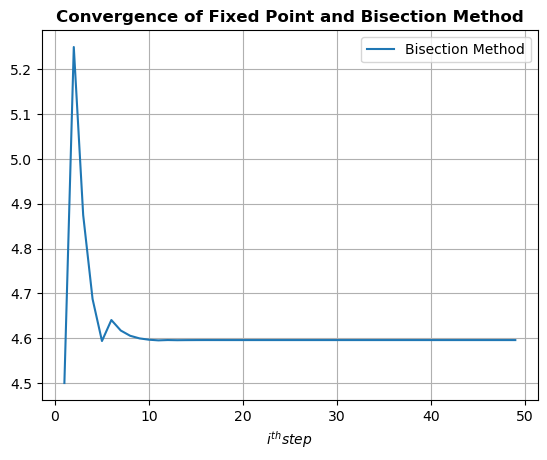

In [8]:
i_vals = np.arange(1, 50)

xfixpt = np.zeros(len(i_vals))
for i_val in i_vals:
    xfixpt[i_val-1] = modified_fixedpoint(g2, -2, kmax=i_val)

xbisect = np.zeros(len(i_vals))
for i_val in i_vals:
    xbisect[i_val-1] = modified_bisection(f, 3, 6, kmax=i_val)

#plt.plot(i_vals, xfixpt, label='Fixed Point Method')
plt.plot(i_vals, xbisect, label='Bisection Method')
plt.title('Convergence of Fixed Point and Bisection Method', fontweight='bold')
plt.xlabel('$i^{th} step$')
plt.legend()
plt.grid()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---